# EXP_12: LIME vs SHAP Explanation Agreement Analysis

Checks whether LIME (EXP_10) and SHAP (EXP_11) agree on the same important medical
evidence passages. High agreement strengthens confidence that the identified passages
are genuinely influential; low agreement flags questions where explanation reliability
is uncertain.

**Metrics computed:**
- Top-1 agreement: do LIME and SHAP agree on the single most influential passage?
- Top-3 Jaccard overlap: what fraction of the top-3 passages overlap?
- Spearman rank correlation: how well do the full passage rankings correlate?
- Kendall's tau: rank concordance metric robust for short rankings (n=5)
- Sign agreement: do LIME and SHAP agree on the direction (help vs hurt) of each passage?
- Agreement conditioned on LIME surrogate R² (low R² → unreliable LIME rankings)
- Agreement by medical severity tier
- Agreement vs faithfulness/correctness correlation

In [1]:
import sys
sys.path.append("..")

import json
import numpy as np
import pandas as pd
from ast import literal_eval
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

import config

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", font_scale=1.1)

RESULTS_DIR = config.RESULTS_EVALSETS_DIR
DEEPEVAL_DIR = config.RESULTS_DEEPEVAL_DIR
FIGURES_DIR = config.RESULTS_FIGURES_DIR

## Configuration

In [2]:
ARCHITECTURES = {
    "Evidence-Graded RAG": {
        "lime_file": "lime_passage_scores_evidence-graded_rag.csv",
        "shap_file": "shap_passage_scores_evidence-graded_rag.csv",
        "xai_dataset_file": "evidence-graded_rag_for_xai.csv",
        "faithfulness_file": "evidence_graded_rag_minilm_faithfulness_20260516_164252.csv",
        "correctness_file": "evidence_graded_rag_minilm_answer_correctness_20260516_164252.csv",
    },
    "Query Decomposition RAG": {
        "lime_file": "lime_passage_scores_query_decomposition_rag.csv",
        "shap_file": "shap_passage_scores_query_decomposition_rag.csv",
        "xai_dataset_file": "query_decomposition_rag_for_xai.csv",
        "faithfulness_file": "decomposition_rag_minilm_faithfulness_20260518_181816.csv",
        "correctness_file": "decomposition_rag_minilm_answer_correctness_20260518_181816.csv",
    },
}

SEVERITY_FILE = "golden_dataset_with_severity.csv"

## Load LIME & SHAP Results

In [7]:
severity_df = pd.read_csv(config.DATA_PROCESSED_DIR / SEVERITY_FILE)[["question_idx", "severity_tier"]]

arch_data = {}

for arch_name, files in ARCHITECTURES.items():
    lime_path = RESULTS_DIR / files["lime_file"]
    shap_path = RESULTS_DIR / files["shap_file"]

    if not lime_path.exists() or not shap_path.exists():
        print(f"Skipping {arch_name}: missing LIME or SHAP results")
        print(f"  LIME exists: {lime_path.exists()}")
        print(f"  SHAP exists: {shap_path.exists()}")
        continue

    lime_df = pd.read_csv(lime_path)
    shap_df = pd.read_csv(shap_path)

    # Load deepeval scores
    faith_df = pd.read_csv(DEEPEVAL_DIR / files["faithfulness_file"])
    faith_col = [c for c in faith_df.columns if "faithfulness" in c.lower() or "Faithfulness" in c][0]

    corr_df = pd.read_csv(DEEPEVAL_DIR / files["correctness_file"])
    corr_col = [c for c in corr_df.columns if "correctness" in c.lower() or "Correctness" in c][0]

    arch_data[arch_name] = {
        "lime": lime_df,
        "shap": shap_df,
        "faithfulness": faith_df,
        "faith_col": faith_col,
        "correctness": corr_df,
        "corr_col": corr_col,
    }
    print(f"{arch_name}: LIME={len(lime_df)} questions, SHAP={len(shap_df)} questions")

    # Verify same questions in both
    lime_qs = set(lime_df["question_idx"])
    shap_qs = set(shap_df["question_idx"])
    overlap = lime_qs & shap_qs
    print(f"  Overlapping questions: {len(overlap)}/{len(lime_qs)}")
    if lime_qs != shap_qs:
        print(f"  LIME-only: {lime_qs - shap_qs}")
        print(f"  SHAP-only: {shap_qs - lime_qs}")

Evidence-Graded RAG: LIME=30 questions, SHAP=30 questions
  Overlapping questions: 30/30
Query Decomposition RAG: LIME=30 questions, SHAP=30 questions
  Overlapping questions: 30/30


## Compute Agreement Metrics

In [8]:
def compute_agreement(lime_row, shap_row, n_passages):
    """Compute agreement metrics between LIME and SHAP for one question.

    Both LIME and SHAP rankings are computed by absolute value — "most influential"
    means the largest effect on answer quality regardless of direction. This is the
    correct comparison: a passage with LIME=-0.08 is more influential than one with
    LIME=+0.02, and should rank higher in both methods.
    """
    lime_scores = np.array([lime_row[f"passage_{i}_influence"] for i in range(n_passages)])
    shap_scores = np.array([shap_row[f"passage_{i}_shap"] for i in range(n_passages)])

    # Rankings by absolute value for both methods (most influential first)
    lime_ranking = np.argsort(np.abs(lime_scores))[::-1]
    shap_ranking = np.argsort(np.abs(shap_scores))[::-1]

    # Top-1 agreement
    top1_agree = int(lime_ranking[0] == shap_ranking[0])

    # Top-3 Jaccard
    lime_top3 = set(lime_ranking[:3])
    shap_top3 = set(shap_ranking[:3])
    top3_jaccard = len(lime_top3 & shap_top3) / len(lime_top3 | shap_top3)
    top3_overlap = len(lime_top3 & shap_top3)

    # Spearman rank correlation on absolute-value ranks
    lime_ranks = stats.rankdata(-np.abs(lime_scores))
    shap_ranks = stats.rankdata(-np.abs(shap_scores))
    spearman_corr, spearman_p = stats.spearmanr(lime_ranks, shap_ranks)

    # Kendall's tau — more robust for short rankings (n=5)
    kendall_corr, kendall_p = stats.kendalltau(lime_ranks, shap_ranks)

    # Pearson on raw scores (directional agreement — do the methods agree on magnitude AND sign?)
    pearson_corr, pearson_p = stats.pearsonr(lime_scores, shap_scores)

    # Sign agreement: for each passage, do LIME and SHAP agree on the direction?
    lime_signs = np.sign(lime_scores)
    shap_signs = np.sign(shap_scores)
    sign_agree_count = int(np.sum(lime_signs == shap_signs))
    sign_agree_rate = sign_agree_count / n_passages

    return {
        "top1_agree": top1_agree,
        "top3_jaccard": top3_jaccard,
        "top3_overlap": top3_overlap,
        "spearman_corr": spearman_corr,
        "spearman_p": spearman_p,
        "kendall_corr": kendall_corr,
        "kendall_p": kendall_p,
        "pearson_corr": pearson_corr,
        "pearson_p": pearson_p,
        "sign_agree_count": sign_agree_count,
        "sign_agree_rate": sign_agree_rate,
        "lime_top1": int(lime_ranking[0]),
        "shap_top1": int(shap_ranking[0]),
    }

In [9]:
agreement_results = {}

for arch_name, data in arch_data.items():
    lime_df = data["lime"]
    shap_df = data["shap"]

    merged = lime_df.merge(shap_df, on="question_idx", suffixes=("_lime", "_shap"))
    n_passages = merged["num_passages_lime"].iloc[0]

    records = []
    for _, row in merged.iterrows():
        lime_row = {f"passage_{i}_influence": row[f"passage_{i}_influence"] for i in range(n_passages)}
        shap_row = {f"passage_{i}_shap": row[f"passage_{i}_shap"] for i in range(n_passages)}

        agreement = compute_agreement(lime_row, shap_row, n_passages)
        agreement["question_idx"] = row["question_idx"]
        agreement["question"] = row["question_lime"] if "question_lime" in row else row["question"]

        # Carry forward LIME R² for conditioning analysis
        if "r_squared" in lime_df.columns:
            agreement["lime_r_squared"] = row["r_squared"]

        # Carry forward SHAP base_value
        if "base_value" in shap_df.columns:
            agreement["shap_base_value"] = row["base_value"]

        records.append(agreement)

    agree_df = pd.DataFrame(records)

    # Join severity tier
    agree_df = agree_df.merge(severity_df, on="question_idx", how="left")

    agreement_results[arch_name] = agree_df

    print(f"\n{'='*60}")
    print(f"{arch_name} — {len(agree_df)} questions")
    print(f"{'='*60}")
    print(f"  Top-1 Agreement Rate:  {agree_df['top1_agree'].mean():.1%}")
    print(f"  Mean Top-3 Jaccard:    {agree_df['top3_jaccard'].mean():.3f}")
    print(f"  Mean Top-3 Overlap:    {agree_df['top3_overlap'].mean():.2f} / 3")
    print(f"  Mean Spearman ρ:       {agree_df['spearman_corr'].mean():.3f}")
    print(f"  Mean Kendall τ:        {agree_df['kendall_corr'].mean():.3f}")
    print(f"  Mean Pearson r:        {agree_df['pearson_corr'].mean():.3f}")
    print(f"  Mean Sign Agreement:   {agree_df['sign_agree_rate'].mean():.1%} ({agree_df['sign_agree_count'].mean():.1f}/5 passages)")


Evidence-Graded RAG — 30 questions
  Top-1 Agreement Rate:  76.7%
  Mean Top-3 Jaccard:    0.550
  Mean Top-3 Overlap:    2.03 / 3
  Mean Spearman ρ:       0.397
  Mean Kendall τ:        0.347
  Mean Pearson r:        0.821
  Mean Sign Agreement:   76.7% (3.8/5 passages)

Query Decomposition RAG — 30 questions
  Top-1 Agreement Rate:  66.7%
  Mean Top-3 Jaccard:    0.577
  Mean Top-3 Overlap:    2.10 / 3
  Mean Spearman ρ:       0.517
  Mean Kendall τ:        0.413
  Mean Pearson r:        0.830
  Mean Sign Agreement:   74.7% (3.7/5 passages)


## Agreement Conditioned on LIME Surrogate R²

If LIME's Ridge surrogate has low R², its coefficients are unreliable. We expect
agreement to be higher when R² is high (LIME's linear approximation is faithful to
the true response surface) and lower when R² is poor.

In [10]:
for arch_name, agree_df in agreement_results.items():
    if "lime_r_squared" not in agree_df.columns:
        print(f"{arch_name}: no R² data available")
        continue

    print(f"\n{'='*60}")
    print(f"{arch_name} — Agreement vs LIME Surrogate R²")
    print(f"{'='*60}")

    # Correlation between R² and agreement metrics
    r2_jaccard = agree_df["lime_r_squared"].corr(agree_df["top3_jaccard"])
    r2_spearman = agree_df["lime_r_squared"].corr(agree_df["spearman_corr"])
    r2_sign = agree_df["lime_r_squared"].corr(agree_df["sign_agree_rate"])
    print(f"  Pearson(R², top3_jaccard)    = {r2_jaccard:.3f}")
    print(f"  Pearson(R², spearman_corr)   = {r2_spearman:.3f}")
    print(f"  Pearson(R², sign_agree_rate) = {r2_sign:.3f}")

    # Split by R² quality
    high_r2 = agree_df[agree_df["lime_r_squared"] >= 0.7]
    mid_r2 = agree_df[(agree_df["lime_r_squared"] >= 0.4) & (agree_df["lime_r_squared"] < 0.7)]
    low_r2 = agree_df[agree_df["lime_r_squared"] < 0.4]

    for label, subset in [("High R²≥0.7", high_r2), ("Mid 0.4≤R²<0.7", mid_r2), ("Low R²<0.4", low_r2)]:
        if len(subset) == 0:
            continue
        print(f"\n  {label} (n={len(subset)}):")
        print(f"    Top-1 agreement:  {subset['top1_agree'].mean():.1%}")
        print(f"    Mean Jaccard:     {subset['top3_jaccard'].mean():.3f}")
        print(f"    Mean Spearman:    {subset['spearman_corr'].mean():.3f}")
        print(f"    Mean Kendall τ:   {subset['kendall_corr'].mean():.3f}")
        print(f"    Mean sign agree:  {subset['sign_agree_rate'].mean():.1%}")


Evidence-Graded RAG — Agreement vs LIME Surrogate R²
  Pearson(R², top3_jaccard)    = 0.277
  Pearson(R², spearman_corr)   = 0.495
  Pearson(R², sign_agree_rate) = -0.323

  High R²≥0.7 (n=11):
    Top-1 agreement:  100.0%
    Mean Jaccard:     0.582
    Mean Spearman:    0.564
    Mean Kendall τ:   0.491
    Mean sign agree:  70.9%

  Mid 0.4≤R²<0.7 (n=13):
    Top-1 agreement:  84.6%
    Mean Jaccard:     0.592
    Mean Spearman:    0.500
    Mean Kendall τ:   0.446
    Mean sign agree:  76.9%

  Low R²<0.4 (n=6):
    Top-1 agreement:  16.7%
    Mean Jaccard:     0.400
    Mean Spearman:    -0.133
    Mean Kendall τ:   -0.133
    Mean sign agree:  86.7%

Query Decomposition RAG — Agreement vs LIME Surrogate R²
  Pearson(R², top3_jaccard)    = -0.045
  Pearson(R², spearman_corr)   = 0.088
  Pearson(R², sign_agree_rate) = 0.381

  High R²≥0.7 (n=9):
    Top-1 agreement:  100.0%
    Mean Jaccard:     0.400
    Mean Spearman:    0.367
    Mean Kendall τ:   0.244
    Mean sign agree:  80

In [11]:
for arch_name, agree_df in agreement_results.items():
    if "severity_tier" not in agree_df.columns:
        print(f"{arch_name}: no severity data")
        continue

    print(f"\n{'='*60}")
    print(f"{arch_name} — Agreement by Severity Tier")
    print(f"{'='*60}")

    for tier in ["Low", "Medium", "High"]:
        subset = agree_df[agree_df["severity_tier"] == tier]
        if len(subset) == 0:
            continue
        print(f"\n  {tier} (n={len(subset)}):")
        print(f"    Top-1 agreement:  {subset['top1_agree'].mean():.1%}")
        print(f"    Mean Jaccard:     {subset['top3_jaccard'].mean():.3f}")
        print(f"    Mean Spearman ρ:  {subset['spearman_corr'].mean():.3f}")
        print(f"    Mean Kendall τ:   {subset['kendall_corr'].mean():.3f}")
        print(f"    Mean sign agree:  {subset['sign_agree_rate'].mean():.1%}")
        if "lime_r_squared" in subset.columns:
            print(f"    Mean LIME R²:     {subset['lime_r_squared'].mean():.3f}")


Evidence-Graded RAG — Agreement by Severity Tier

  Low (n=10):
    Top-1 agreement:  90.0%
    Mean Jaccard:     0.440
    Mean Spearman ρ:  0.350
    Mean Kendall τ:   0.300
    Mean sign agree:  76.0%
    Mean LIME R²:     0.557

  Medium (n=10):
    Top-1 agreement:  70.0%
    Mean Jaccard:     0.590
    Mean Spearman ρ:  0.280
    Mean Kendall τ:   0.260
    Mean sign agree:  74.0%
    Mean LIME R²:     0.626

  High (n=10):
    Top-1 agreement:  70.0%
    Mean Jaccard:     0.620
    Mean Spearman ρ:  0.560
    Mean Kendall τ:   0.480
    Mean sign agree:  80.0%
    Mean LIME R²:     0.535

Query Decomposition RAG — Agreement by Severity Tier

  Low (n=10):
    Top-1 agreement:  70.0%
    Mean Jaccard:     0.570
    Mean Spearman ρ:  0.600
    Mean Kendall τ:   0.520
    Mean sign agree:  74.0%
    Mean LIME R²:     0.538

  Medium (n=10):
    Top-1 agreement:  70.0%
    Mean Jaccard:     0.670
    Mean Spearman ρ:  0.600
    Mean Kendall τ:   0.460
    Mean sign agree:  74.0%
  

## Per-Passage Sign Agreement and Directional Analysis

For each passage position, check how often LIME and SHAP agree on the *direction*
of influence (positive = helps, negative = hurts). Also compare the actual values
to understand which passages show the most divergence between methods.

In [12]:
for arch_name, data in arch_data.items():
    lime_df = data["lime"]
    shap_df = data["shap"]
    merged = lime_df.merge(shap_df, on="question_idx", suffixes=("_lime", "_shap"))
    n_passages = merged["num_passages_lime"].iloc[0]

    print(f"\n{'='*60}")
    print(f"{arch_name} — Per-Passage Analysis")
    print(f"{'='*60}")

    print(f"\n  {'Pos':<5} {'LIME mean':>10} {'SHAP mean':>10} {'Sign Agree':>12} {'Pearson r':>10} {'Mean |Δ|':>10}")
    print(f"  {'-'*57}")

    for i in range(n_passages):
        lime_vals = merged[f"passage_{i}_influence"].values
        shap_vals = merged[f"passage_{i}_shap"].values

        sign_agree = np.mean(np.sign(lime_vals) == np.sign(shap_vals))
        pearson_r = np.corrcoef(lime_vals, shap_vals)[0, 1]
        mean_abs_diff = np.mean(np.abs(lime_vals - shap_vals))

        print(f"  P{i:<4} {lime_vals.mean():>+10.4f} {shap_vals.mean():>+10.4f} "
              f"{sign_agree:>11.1%} {pearson_r:>10.3f} {mean_abs_diff:>10.4f}")

    # Overall sign agreement
    all_lime = np.array([merged[f"passage_{i}_influence"].values for i in range(n_passages)]).flatten()
    all_shap = np.array([merged[f"passage_{i}_shap"].values for i in range(n_passages)]).flatten()
    overall_sign = np.mean(np.sign(all_lime) == np.sign(all_shap))
    overall_pearson = np.corrcoef(all_lime, all_shap)[0, 1]
    print(f"\n  Overall (all {n_passages * len(merged)} passage-level pairs):")
    print(f"    Sign agreement: {overall_sign:.1%}")
    print(f"    Pearson r:      {overall_pearson:.3f}")


Evidence-Graded RAG — Per-Passage Analysis

  Pos    LIME mean  SHAP mean   Sign Agree  Pearson r   Mean |Δ|
  ---------------------------------------------------------
  P0       +0.0201    +0.0287       90.0%      0.885     0.0159
  P1       +0.0179    +0.0315       80.0%      0.912     0.0183
  P2       +0.0021    +0.0085       83.3%      0.833     0.0151
  P3       +0.0018    +0.0019       66.7%      0.796     0.0140
  P4       -0.0043    -0.0070       63.3%      0.475     0.0090

  Overall (all 150 passage-level pairs):
    Sign agreement: 76.7%
    Pearson r:      0.873

Query Decomposition RAG — Per-Passage Analysis

  Pos    LIME mean  SHAP mean   Sign Agree  Pearson r   Mean |Δ|
  ---------------------------------------------------------
  P0       +0.0127    +0.0363       76.7%      0.900     0.0357
  P1       +0.0407    +0.0901       70.0%      0.924     0.0539
  P2       +0.0112    +0.0476       83.3%      0.833     0.0429
  P3       +0.0107    +0.0232       56.7%      0.6

In [13]:
for arch_name, agree_df in agreement_results.items():
    data = arch_data[arch_name]
    faith_df = data["faithfulness"]
    faith_col = data["faith_col"]
    corr_df = data["correctness"]
    corr_col = data["corr_col"]

    # Merge faithfulness
    if "question_idx" in faith_df.columns:
        merged = agree_df.merge(faith_df[["question_idx", faith_col]], on="question_idx", how="left")
    else:
        merged = agree_df.copy()
        merged[faith_col] = faith_df[faith_col].values[:len(merged)]

    # Merge correctness
    if "question_idx" in corr_df.columns:
        merged = merged.merge(corr_df[["question_idx", corr_col]], on="question_idx", how="left")
    else:
        merged[corr_col] = corr_df[corr_col].values[:len(merged)]

    print(f"\n{'='*60}")
    print(f"{arch_name}")
    print(f"{'='*60}")

    # Agreement vs Faithfulness
    if merged[faith_col].nunique() <= 1:
        print(f"\n  Faithfulness: all {len(merged)} questions score {merged[faith_col].iloc[0]:.1f}")
        print(f"    -> Zero variance — correlation undefined")
    else:
        r1 = merged["top3_jaccard"].corr(merged[faith_col])
        r2 = merged["spearman_corr"].corr(merged[faith_col])
        r3 = merged["sign_agree_rate"].corr(merged[faith_col])
        print(f"\n  Faithfulness (unique values: {merged[faith_col].nunique()}):")
        print(f"    Pearson(top3_jaccard, faithfulness)  = {r1:.3f}")
        print(f"    Pearson(spearman_corr, faithfulness) = {r2:.3f}")
        print(f"    Pearson(sign_agree, faithfulness)    = {r3:.3f}")

    # Agreement vs Correctness
    if merged[corr_col].nunique() <= 1:
        print(f"\n  Correctness: all {len(merged)} questions score {merged[corr_col].iloc[0]:.1f}")
        print(f"    -> Zero variance — correlation undefined")
    else:
        r4 = merged["top3_jaccard"].corr(merged[corr_col])
        r5 = merged["spearman_corr"].corr(merged[corr_col])
        r6 = merged["sign_agree_rate"].corr(merged[corr_col])
        print(f"\n  Answer Correctness (unique values: {merged[corr_col].nunique()}):")
        print(f"    Pearson(top3_jaccard, correctness)  = {r4:.3f}")
        print(f"    Pearson(spearman_corr, correctness) = {r5:.3f}")
        print(f"    Pearson(sign_agree, correctness)    = {r6:.3f}")

    # Breakdown: high-agreement vs low-agreement questions
    high_agree = merged[merged["top3_jaccard"] >= 0.5]
    low_agree = merged[merged["top3_jaccard"] < 0.5]
    print(f"\n  High agreement (Jaccard>=0.5): {len(high_agree)} questions")
    if len(high_agree) > 0:
        print(f"    Mean faithfulness: {high_agree[faith_col].mean():.3f}")
        print(f"    Mean correctness:  {high_agree[corr_col].mean():.3f}")
    print(f"  Low agreement (Jaccard<0.5): {len(low_agree)} questions")
    if len(low_agree) > 0:
        print(f"    Mean faithfulness: {low_agree[faith_col].mean():.3f}")
        print(f"    Mean correctness:  {low_agree[corr_col].mean():.3f}")


Evidence-Graded RAG

  Faithfulness (unique values: 3):
    Pearson(top3_jaccard, faithfulness)  = 0.048
    Pearson(spearman_corr, faithfulness) = 0.008
    Pearson(sign_agree, faithfulness)    = 0.152

  Answer Correctness (unique values: 7):
    Pearson(top3_jaccard, correctness)  = 0.301
    Pearson(spearman_corr, correctness) = 0.472
    Pearson(sign_agree, correctness)    = -0.003

  High agreement (Jaccard>=0.5): 25 questions
    Mean faithfulness: 0.987
    Mean correctness:  0.908
  Low agreement (Jaccard<0.5): 5 questions
    Mean faithfulness: 1.000
    Mean correctness:  0.720

Query Decomposition RAG

  Faithfulness: all 30 questions score 1.0
    -> Zero variance — correlation undefined

  Answer Correctness (unique values: 9):
    Pearson(top3_jaccard, correctness)  = 0.078
    Pearson(spearman_corr, correctness) = 0.153
    Pearson(sign_agree, correctness)    = -0.075

  High agreement (Jaccard>=0.5): 26 questions
    Mean faithfulness: 1.000
    Mean correctness:  0.8

## Visualisation: Agreement Distribution

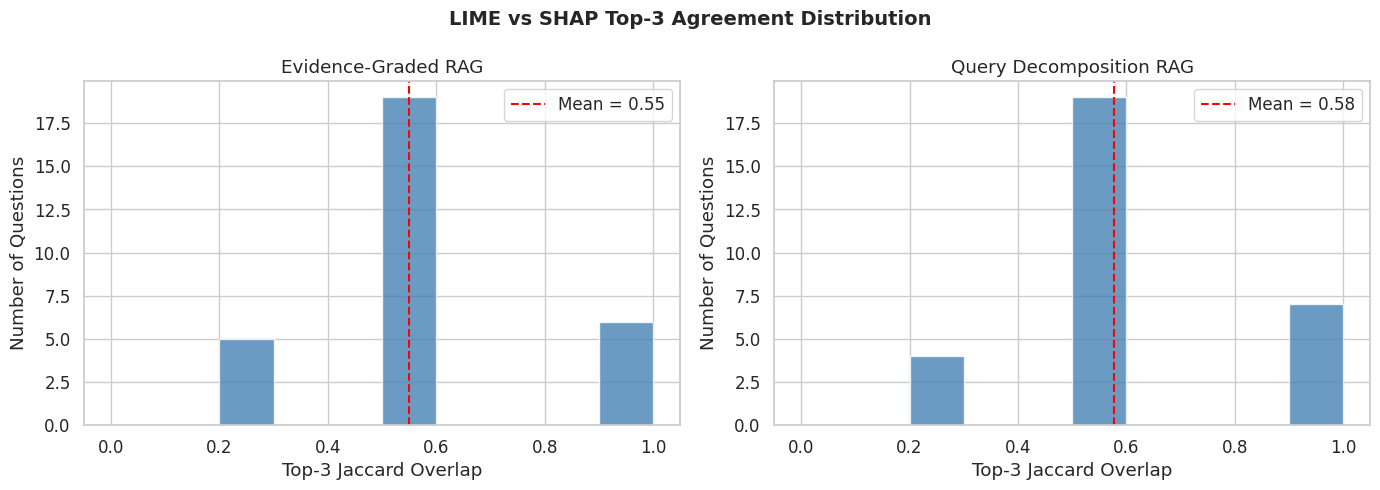

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (arch_name, agree_df) in enumerate(agreement_results.items()):
    ax = axes[ax_idx]

    ax.hist(agree_df["top3_jaccard"], bins=np.arange(0, 1.1, 0.1),
            color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(x=agree_df["top3_jaccard"].mean(), color="red", linestyle="--",
              label=f"Mean = {agree_df['top3_jaccard'].mean():.2f}")
    ax.set_xlabel("Top-3 Jaccard Overlap")
    ax.set_ylabel("Number of Questions")
    ax.set_title(f"{arch_name}")
    ax.legend()

plt.suptitle("LIME vs SHAP Top-3 Agreement Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xai_agreement_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisation: Agreement vs Faithfulness Scatter

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


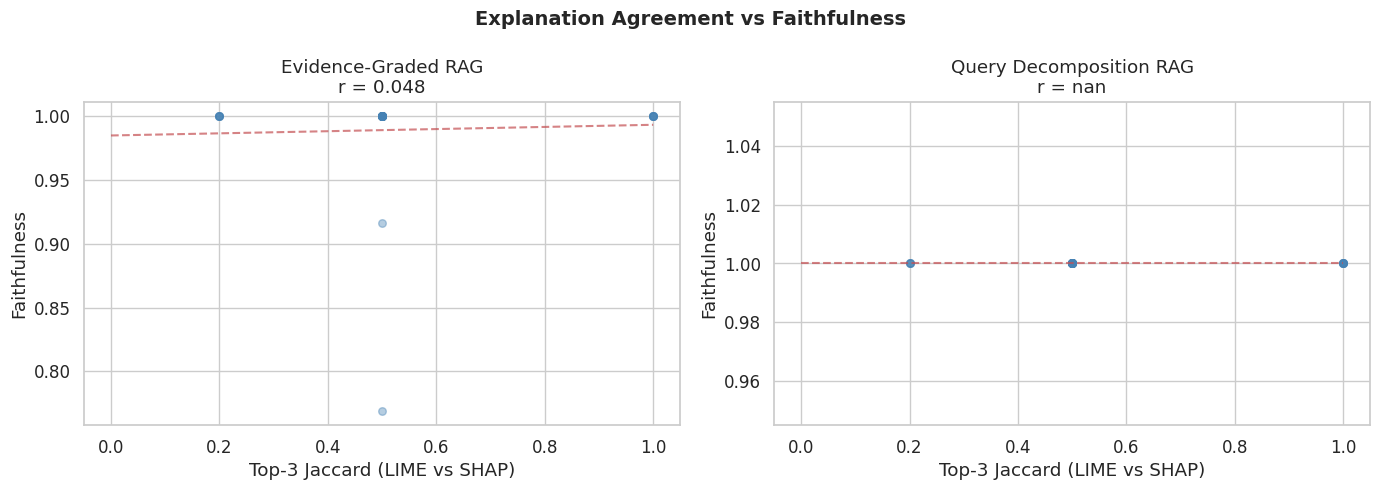

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, (arch_name, agree_df) in enumerate(agreement_results.items()):
    data = arch_data[arch_name]
    faith_df = data["faithfulness"]
    faith_col = data["faith_col"]

    if "question_idx" in faith_df.columns:
        merged = agree_df.merge(faith_df[["question_idx", faith_col]], on="question_idx", how="left")
    else:
        merged = agree_df.copy()
        merged[faith_col] = faith_df[faith_col].values[:len(merged)]

    ax = axes[ax_idx]
    ax.scatter(merged["top3_jaccard"], merged[faith_col], alpha=0.4, s=30, c="steelblue")

    # Trend line
    z = np.polyfit(merged["top3_jaccard"].dropna(), merged[faith_col].dropna(), 1)
    p = np.poly1d(z)
    x_range = np.linspace(0, 1, 100)
    ax.plot(x_range, p(x_range), "r--", alpha=0.7)

    r = merged["top3_jaccard"].corr(merged[faith_col])
    ax.set_xlabel("Top-3 Jaccard (LIME vs SHAP)")
    ax.set_ylabel("Faithfulness")
    ax.set_title(f"{arch_name}\nr = {r:.3f}")

plt.suptitle("Explanation Agreement vs Faithfulness", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xai_agreement_vs_faithfulness.png", dpi=150, bbox_inches="tight")
plt.show()

## Disagreement Case Analysis

Identify questions where LIME and SHAP strongly disagree — these may reveal
cases where one method is more reliable than the other.

In [16]:
for arch_name, agree_df in agreement_results.items():
    print(f"\n{'='*60}")
    print(f"{arch_name} — Disagreement Cases (lowest Jaccard)")
    print(f"{'='*60}")

    disagree = agree_df[agree_df["top3_jaccard"] == 0].copy()
    if len(disagree) == 0:
        disagree = agree_df.nsmallest(5, "top3_jaccard")
        print(f"  No complete disagreements; showing 5 lowest Jaccard:")

    for _, row in disagree.head(10).iterrows():
        print(f"\n  Q{int(row['question_idx'])}: {row['question'][:80]}...")
        print(f"    LIME top-1: P{int(row['lime_top1'])}  |  SHAP top-1: P{int(row['shap_top1'])}")
        print(f"    Jaccard: {row['top3_jaccard']:.2f}  |  Spearman: {row['spearman_corr']:.3f}  |  Sign agree: {row['sign_agree_rate']:.0%}")
        if "lime_r_squared" in row:
            print(f"    LIME R²: {row['lime_r_squared']:.3f}")
        if "severity_tier" in row:
            print(f"    Severity: {row['severity_tier']}")


Evidence-Graded RAG — Disagreement Cases (lowest Jaccard)
  No complete disagreements; showing 5 lowest Jaccard:

  Q27: Is robotically assisted laparoscopic radical prostatectomy less invasive than re...
    LIME top-1: P0  |  SHAP top-1: P3
    Jaccard: 0.20  |  Spearman: -0.900  |  Sign agree: 100%
    LIME R²: 0.347
    Severity: Medium

  Q33: Do familiar teammates request and accept more backup?...
    LIME top-1: P2  |  SHAP top-1: P2
    Jaccard: 0.20  |  Spearman: 0.200  |  Sign agree: 60%
    LIME R²: 0.430
    Severity: Low

  Q51: Is there a role for fondaparinux in perioperative bridging?...
    LIME top-1: P1  |  SHAP top-1: P1
    Jaccard: 0.20  |  Spearman: 0.100  |  Sign agree: 80%
    LIME R²: 0.728
    Severity: High

  Q97: Does feeding tube insertion and its timing improve survival?...
    LIME top-1: P4  |  SHAP top-1: P2
    Jaccard: 0.20  |  Spearman: -1.000  |  Sign agree: 80%
    LIME R²: 0.132
    Severity: Medium

  Q118: Health care for immigrants in Europ

## Summary Table: Architecture-Level Agreement

In [17]:
summary_rows = []
for arch_name, agree_df in agreement_results.items():
    summary_rows.append({
        "Architecture": arch_name,
        "N Questions": len(agree_df),
        "Top-1 Agreement": f"{agree_df['top1_agree'].mean():.1%}",
        "Mean Jaccard (Top-3)": f"{agree_df['top3_jaccard'].mean():.3f}",
        "Mean Overlap (Top-3)": f"{agree_df['top3_overlap'].mean():.2f}/3",
        "Mean Spearman ρ": f"{agree_df['spearman_corr'].mean():.3f}",
        "Mean Kendall τ": f"{agree_df['kendall_corr'].mean():.3f}",
        "Mean Pearson r": f"{agree_df['pearson_corr'].mean():.3f}",
        "Mean Sign Agree": f"{agree_df['sign_agree_rate'].mean():.1%}",
        "Complete Agree (J=1)": f"{(agree_df['top3_jaccard'] == 1.0).sum()}",
        "Complete Disagree (J=0)": f"{(agree_df['top3_jaccard'] == 0.0).sum()}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Architecture,N Questions,Top-1 Agreement,Mean Jaccard (Top-3),Mean Overlap (Top-3),Mean Spearman ρ,Mean Kendall τ,Mean Pearson r,Mean Sign Agree,Complete Agree (J=1),Complete Disagree (J=0)
0,Evidence-Graded RAG,30,76.7%,0.550,2.03/3,0.397,0.347,0.821,76.7%,6,0
1,Query Decomposition RAG,30,66.7%,0.577,2.10/3,0.517,0.413,0.830,74.7%,7,0


## Save Agreement Scores for Downstream Use

These scores feed into EXP_16 (final comparative analysis) as the explainability
component of the confidence formula.

In [18]:
for arch_name, agree_df in agreement_results.items():
    output_path = RESULTS_DIR / f"xai_agreement_{arch_name.lower().replace(' ', '_')}.csv"
    agree_df.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

Saved: /content/results/eval_datasets/xai_agreement_evidence-graded_rag.csv
Saved: /content/results/eval_datasets/xai_agreement_query_decomposition_rag.csv
